📌 Extracão

In [2]:
import pandas as pd

In [3]:
dados = pd.read_json('/content/TelecomX_Data.json')
dados

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [13]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [12]:
dados.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

🔧 Transformação

In [18]:
# Normalizando colunas
dados_plano = pd.json_normalize(dados['customer'])
telefone = pd.json_normalize(dados['phone'])
conta = pd.json_normalize(dados['account'])

# Concatenar colunas
df_final = pd.concat(
    [dados[['customerID', 'Churn']],
     dados_plano ,
     telefone,
     conta],
    axis=1
)

dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [19]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [20]:
#validar dados vazios
dados['Churn'].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869
,224


In [22]:
for col in dados.columns:
    print(f"\n🔍 Columna: {col}")
    print(dados[col].value_counts(dropna=False))


🔍 Columna: customerID
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

🔍 Columna: Churn
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

🔍 Columna: customer
customer
{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 1}         223
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 1}       192
{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 72}       77
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 72}     76
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 2}        74
                                                                                                ... 
{'gender': 'Female', 'Senior

In [23]:
#Corrigir tipo de dado
dados['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')
print(dados['Charges.Total'].dtype)

float64


In [24]:
#Trocar valores vazios por NaN
dados.replace(r'^\s*$', pd.NA, regex=True, inplace=True)

In [35]:
print("Valores nulos por coluna:")
print(dados.isna().sum())

Valores nulos por coluna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [28]:
#Eliminar registros nulo
dados = dados.dropna(subset=['Churn'])
dados = dados.dropna(subset=['Charges.Total'])


In [33]:
print(dados.duplicated().sum())


0


In [36]:
#Visualizar dataframe
print("\nVisualizar dataframe:")
print(df_final.info())
print(df_final.head())


Visualizar dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   Contract          7267 non-null   object 
 10  PaperlessBilling  7267 non-null   object 
 11  PaymentMethod     7267 non-null   object 
 12  Charges.Monthly   7267 non-null   float64
 13  Charges.Total     7267 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 795.0+ KB
None
   customerID Churn  gender  SeniorCitizen Partn

In [37]:
#Criar colunas"
dados['Contas_Diarias'] = dados['Charges.Monthly'] / 30

In [41]:
#Verificar coluna
dados[['customerID','Charges.Monthly', 'Contas_Diarias']].head()

,customerID,Charges.Monthly,Contas_Diarias
0,0002-ORFBO,65.6,2.186667
1,0003-MKNFE,59.9,1.996667
2,0004-TLHLJ,73.9,2.463333
3,0011-IGKFF,98.0,3.266667
4,0013-EXCHZ,83.9,2.796667


📊 Carga e análise

In [42]:
dados.describe()

,SeniorCitizen,tenure,Charges.Monthly,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2.157337
std,0.369074,24.571773,30.129572,1.004319
min,0.000000,0.000000,18.250000,0.608333
25%,0.000000,9.000000,35.425000,1.180833
50%,0.000000,29.000000,70.300000,2.343333
75%,0.000000,55.000000,89.875000,2.995833
max,1.000000,72.000000,118.750000,3.958333


In [44]:
dados['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [45]:
dados['Contract'].value_counts(normalize=True) * 100

,proportion
Contract,
Month-to-month,55.112151
Two year,23.985138
One year,20.902711


In [48]:
dados['gender'].value_counts(normalize=True) * 100

,proportion
gender,
Male,50.571075
Female,49.428925


In [49]:
#Visualizações:
dados['rango_tenure'] = pd.cut(dados['tenure'],
                                 bins=[0, 6, 12, 24, 36, 48, 60, 72],
                                 labels=['0-6', '7-12', '13-24', '25-36', '37-48', '49-60', '61-72'],
                                 right=True)

In [57]:
def grafico_abandono(columna_grupo, titulo, xlabel, nombre_archivo=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Calcular
    tabela = dados.groupby([columna_grupo, 'Churn'], observed=False).size().reset_index(name='count')

    # Criar grupo sim ou não
    tabela_pivot = tabela.pivot(index=columna_grupo, columns='Churn', values='count').fillna(0)

    if 'Yes' not in tabela_pivot.columns:
        tabela_pivot['Yes'] = 0
    if 'No' not in tabela_pivot.columns:
        tabela_pivot['No'] = 0

    # Calcular total
    tabela_pivot['Total'] = tabela_pivot['Yes'] + tabela_pivot['No']
    tabela_pivot['ChurnPercent'] = (tabela_pivot['Yes'] / tabela_pivot['Total'] * 100).round(1)

    # Gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    tabela_pivot[['No', 'Yes']].plot(kind='bar', stacked=False, ax=ax, color=['#8dd3c7', '#fb8072'])

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Número de Clientes")
    ax.legend(title='Churn')
    plt.xticks(rotation=45)

    for i, grupo in enumerate(tabela_pivot.index):
        no_val = tabela_pivot.loc[grupo, 'No']
        yes_val = tabela_pivot.loc[grupo, 'Yes']

        x_base = i

        ax.text(x_base - 0.15, no_val + 10, int(no_val), ha='center', fontsize=9)
        ax.text(x_base + 0.15, yes_val + 10, int(yes_val), ha='center', fontsize=9)

        ax.text(x_base + 0.15, yes_val + 90,
                f"{tabela_pivot.loc[grupo, 'ChurnPercent']}%",
                ha='center', fontsize=10, color='red', fontweight='bold')

    plt.tight_layout()

    plt.show()

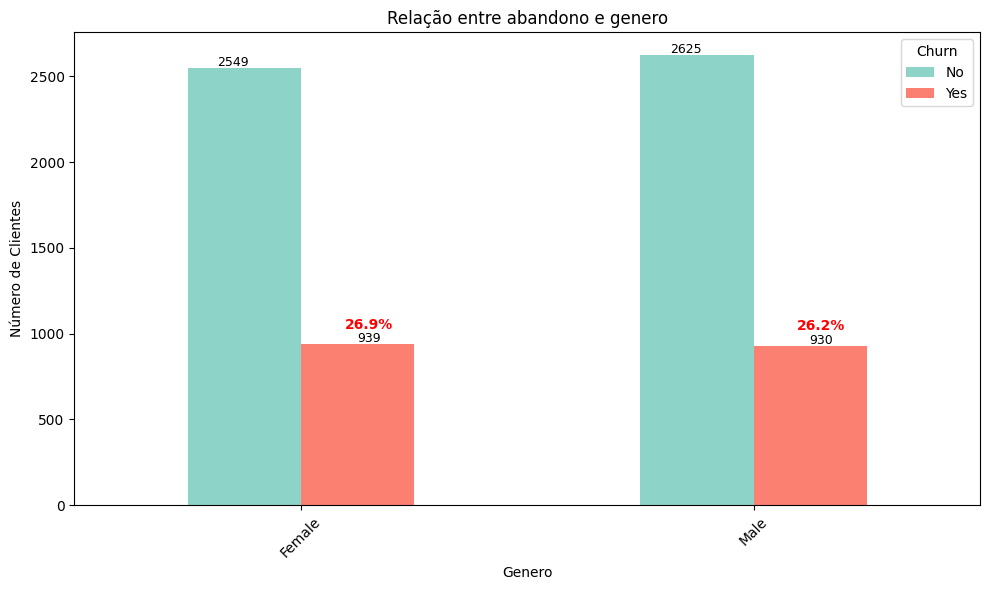

In [58]:
grafico_abandono('gender', 'Relação entre abandono e genero', 'Genero','abandono_genero.png')

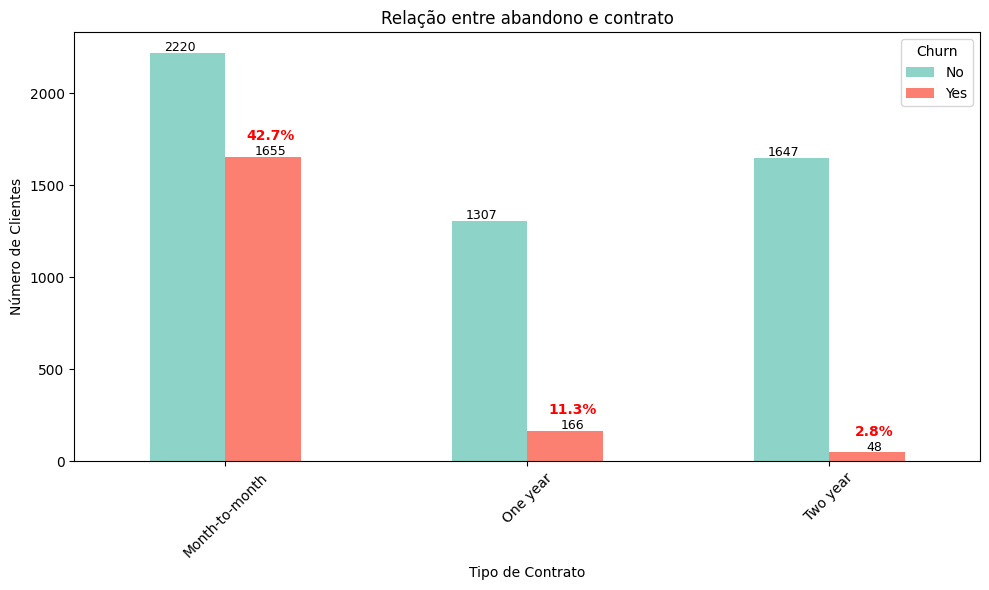

In [59]:
grafico_abandono('Contract', 'Relação entre abandono e contrato', 'Tipo de Contrato','abandono_contrato.png')

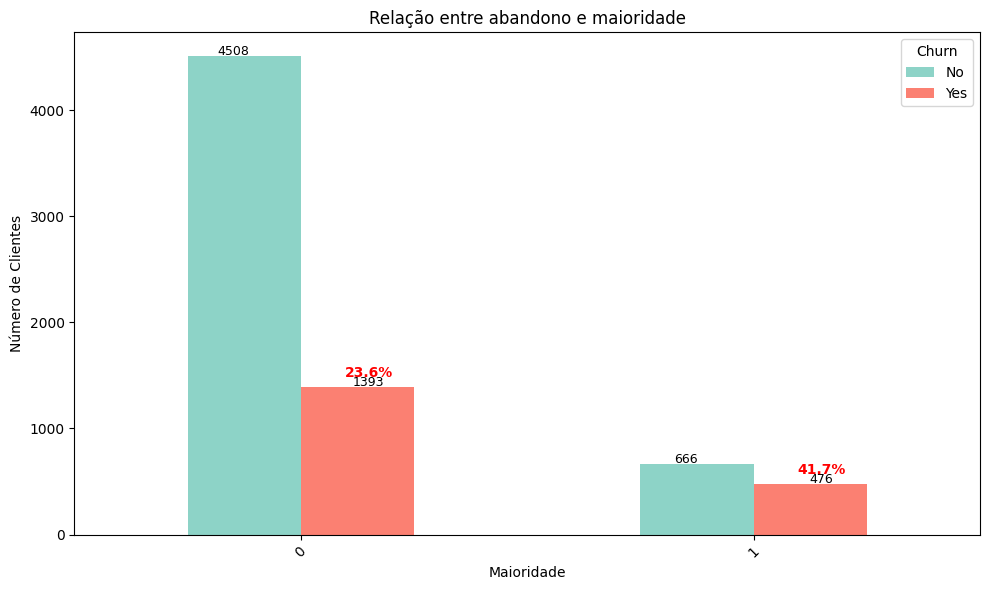

In [63]:
grafico_abandono('SeniorCitizen', 'Relação entre abandono e maioridade', 'Maioridade','abandono_adulto_mayor.png')


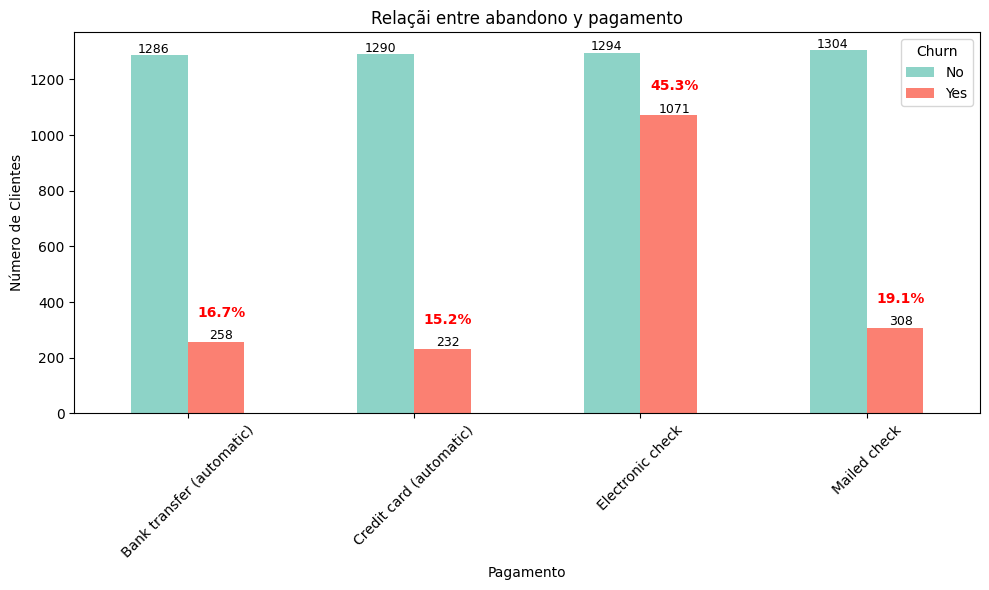

In [65]:
grafico_abandono('PaymentMethod', 'Relaçãi entre abandono y pagamento', 'Pagamento','abandono_metodo_pago.png')


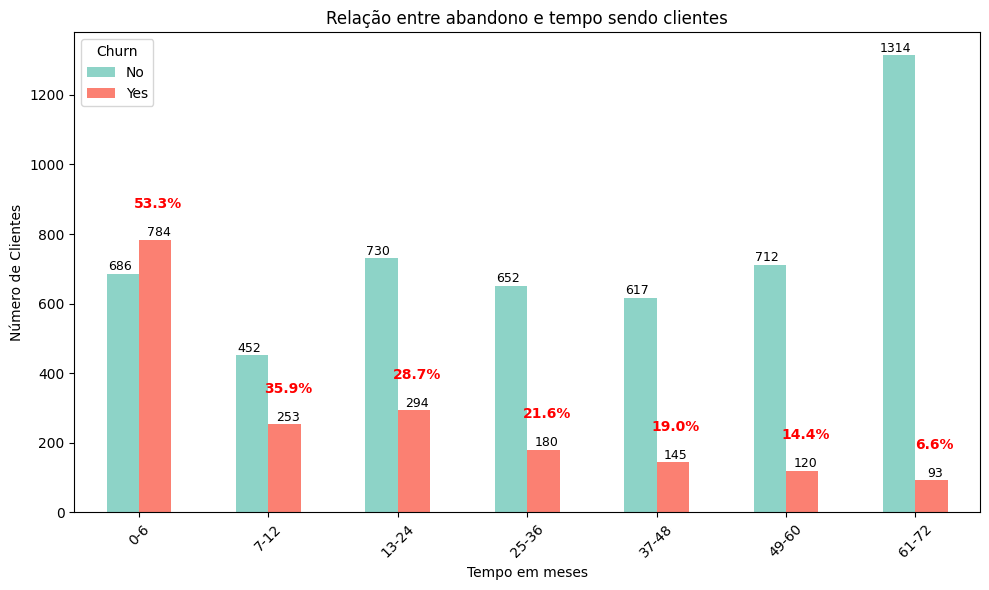

In [67]:
grafico_abandono('rango_tenure', 'Relação entre abandono e tempo sendo clientes', 'Tempo em meses','abandono_antiguedad.png')


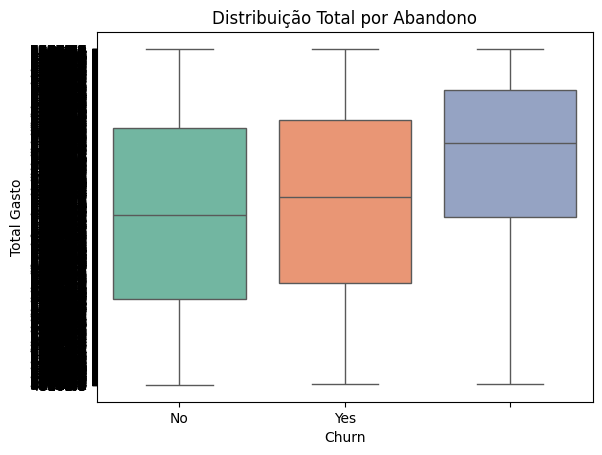

In [74]:
sns.boxplot(data=dados, x='Churn', y='Charges.Total', hue='Churn', palette='Set2', dodge=False)
plt.title('Distribuição Total por Abandono')
plt.xlabel('Churn')
plt.ylabel('Total Gasto')
plt.legend([],[], frameon=False)
plt.savefig('abandono_total_gasto.png')
plt.show()


In [72]:
dados.groupby('Churn')['Charges.Total'].describe()

,count,unique,top,freq
Churn,,,,
,224,223,19.55,2
No,5174,4966,,11
Yes,1869,1732,20.2,6


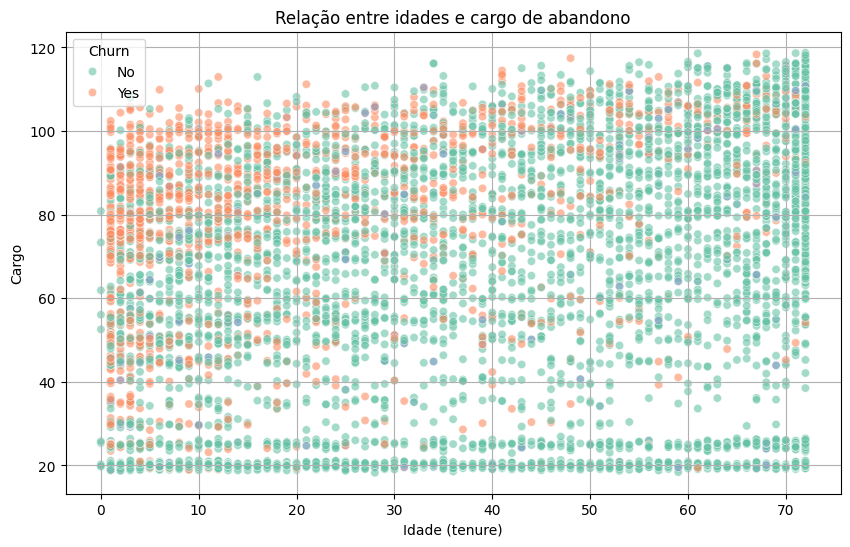

In [73]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_final, x='tenure', y='Charges.Monthly', hue='Churn', alpha=0.6, palette='Set2')
plt.title('Relação entre idades e cargo de abandono')
plt.xlabel('Idade (tenure)')
plt.ylabel('Cargo')
plt.grid(True)
plt.show()

📄Relatorio Final


---


**Introdução**


---



Identifiquei fatores associados à evasão de clientes (churn) para criar estratégias de retenção, melhorar a experiência do cliente e reduzir cancelamentos.



---



**Tratamento de Dados**

---



 - Dados carregados de um arquivo JSON no GitHub.

 - Colunas com dicionários aninhados foram "achatadas" para análise.

 - Limpeza incluiu:

      Conversão de Charges.Total para numérico.

      Identificação de valores nulos (11 registros).

      Verificação de valores únicos e outliers em colunas categóricas.



---



**Validação da coluna Churn.**



---


 - Criada a coluna Cuentas_Diarias (estimativa de faturamento diário).

 - O dataset ficou pronto para análise exploratória.

 - Análise Exploratória (EDA)
Variáveis Numéricas

 - Métricas analisadas: média, mediana, desvio padrão, mínimo, máximo e percentis.

 - Insights:

      Clientes com alta cobrança diária.

      Casos de pouca antiguidade, mas alta fatura.

      Alta dispersão nas tarifas mensais e totais.


Variáveis Categóricas

1. Gênero: Sem impacto significativo no churn (aprox. 27% mulheres, 26% homens).

2. Tipo de Contrato: Contratos mensais apresentam maior churn; contratos de 1-2 anos reduzem abandono.

3. Serviço de Internet: Fibra óptica tem maior churn (41,9%), DSL 19%, sem internet 7,4%.

4. Idade / SeniorCitizen: Adultos maiores têm churn mais alto (41,7% vs 23,7%).

5. Método de Pagamento: Cheque eletrônico apresenta maior churn (45,3%) comparado a transferência ou cartão de crédito (~16%).

6. Antiguidade do Cliente: Clientes novos (0–6 meses) têm churn de 53%; diminui conforme aumenta o tenure.

7. Gasto Total: Clientes que saem gastam menos em média (1.530 vs 2.650).

8. Carga Mensal: Alta carga em clientes novos aumenta risco de churn; clientes antigos com cargas baixas/medias tendem a permanecer.



---



**Conclusões**



---



 - Contratos mensais e baixa antiguidade aumentam a probabilidade de churn.

 - Gasto total menor indica clientes mais vulneráveis.

 - Tipo de serviço de internet e método de pagamento influenciam a evasão.

 - Primeiros meses do cliente são críticos para retenção.

 - Recomendações Estratégicas

 - Incentivar contratos longos com benefícios.

 - Criar plano de fidelização nos primeiros meses.

 - Monitorar clientes de baixo tenure e baixo gasto com alertas e campanhas.

 - Melhorar experiência de usuários de fibra óptica.

 - Otimizar métodos de pagamento, promovendo opções automáticas e seguras.

 - Implementar modelos preditivos de churn para ações preventivas.